# Brain Tumor MRI Segmentation — Multi-Model Comparison
### Models: U-Net · ResNet-UNet · SegNet · DeepLabV3+ (Baseline) · DeepLabV3+ (Transformer Attention)
### Dataset: Task01_BrainTumour (NIfTI .nii.gz format) · Real pixel-level masks from labelsTr

## 1. Install Dependencies

In [ ]:
!pip install tqdm scikit-learn matplotlib seaborn opencv-python-headless pandas nibabel

## 2. Imports

In [ ]:
import os
import cv2
import numpy as np
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Dataset Configuration
Your Task01_BrainTumour dataset on Google Drive has the following structure:
```
Task01_BrainTumour/
├── imagesTr/          ← 3D MRI volumes (.nii.gz), multi-channel
├── labelsTr/          ← 3D segmentation masks (.nii.gz), REAL pixel-level masks
├── imagesTs/          ← Test MRI volumes (no masks)
└── dataset.json       ← Dataset metadata
```
**Key difference from old dataset:** This dataset has REAL segmentation masks in `labelsTr/`.
- Label 0 = Background (healthy tissue)
- Label 1 = Edema
- Label 2 = Non-enhancing tumor core
- Label 3 = Enhancing tumor

We binarize: **any label > 0 = tumor (1), label 0 = background (0)**.

Each .nii.gz file is a **3D volume** (H × W × D slices). We extract 2D slices and convert to JPG-equivalent arrays for training.

In [ ]:
# ── Update this path to match your Google Drive location ────────────────────
DATASET_PATH = "/content/drive/MyDrive/Task01_BrainTumour/Task01_BrainTumour"

IMAGES_TR_DIR = os.path.join(DATASET_PATH, "imagesTr")
LABELS_TR_DIR = os.path.join(DATASET_PATH, "labelsTr")
IMAGES_TS_DIR = os.path.join(DATASET_PATH, "imagesTs")

IMG_SIZE = 128   # ← 128×128 slices (RAM-efficient; change to 240 if Colab Pro)

# Quick sanity check
img_files   = sorted([f for f in os.listdir(IMAGES_TR_DIR) if f.endswith('.nii.gz')])
label_files = sorted([f for f in os.listdir(LABELS_TR_DIR) if f.endswith('.nii.gz')])

print(f"Training image volumes : {len(img_files)}")
print(f"Training label volumes : {len(label_files)}")
print(f"IMG_SIZE               : {IMG_SIZE}")
print(f"\nFirst 5 image files    : {img_files[:5]}")
print(f"First 5 label files    : {label_files[:5]}")

Training image volumes : 495
Training label volumes : 485
IMG_SIZE               : 128

First 5 image files    : ['._BRATS_001.nii.gz', '._BRATS_002.nii.gz', '._BRATS_004.nii.gz', '._BRATS_006.nii.gz', '._BRATS_027.nii.gz']
First 5 label files    : ['._BRATS_166.nii.gz', 'BRATS_001.nii.gz', 'BRATS_002.nii.gz', 'BRATS_003.nii.gz', 'BRATS_004.nii.gz']


## 5. NIfTI → 2D Slice Preprocessing
**Pipeline for each .nii.gz volume:**
1. Load 3D volume with nibabel → shape (H, W, D, C) where C = MRI modalities (4 channels in BraTS)
2. Take the FLAIR channel (channel 0) as the primary image
3. Load corresponding label volume → shape (H, W, D)
4. Extract 2D axial slices (along depth axis D)
5. Skip nearly-empty slices (< 1% tumor pixels) to remove uninformative blank slices
6. Resize each slice to IMG_SIZE × IMG_SIZE
7. Normalize image to [0, 1]; binarize mask (label > 0 = tumor)

In [ ]:
def load_nifti_slices(images_dir, labels_dir, img_size=IMG_SIZE,
                      min_tumor_fraction=0.01, max_slices_per_volume=20):
    """
    Load 2D axial slices from NIfTI volumes.

    Args:
        images_dir          : path to imagesTr folder
        labels_dir          : path to labelsTr folder
        img_size            : output spatial size (img_size × img_size)
        min_tumor_fraction  : skip slices with fewer tumor pixels than this fraction
        max_slices_per_volume: cap slices per volume to control RAM usage

    Returns:
        X : (N, H, W, 1)  normalised grayscale slices  float32
        Y : (N, H, W, 1)  binary segmentation masks     float32
    """
    X, Y = [], []

    img_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.nii.gz') and not f.startswith('._')])

    for fname in tqdm(img_files, desc="Loading NIfTI volumes"):
        img_path   = os.path.join(images_dir, fname)

        # Build the matching label filename
        # imagesTr: BRATS_001.nii.gz → labelsTr: BRATS_001.nii.gz
        label_fname = fname  # same name in both folders
        label_path  = os.path.join(labels_dir, label_fname)

        if not os.path.exists(label_path):
            print(f"  [WARN] No label for {fname}, skipping.")
            continue

        # Load volumes
        img_nib   = nib.load(img_path)
        label_nib = nib.load(label_path)

        img_vol   = img_nib.get_fdata()    # (H, W, D)  or  (H, W, D, C)
        label_vol = label_nib.get_fdata()  # (H, W, D)

        # If multi-channel (4 MRI modalities), take FLAIR = channel 0
        if img_vol.ndim == 4:
            img_vol = img_vol[..., 0]

        depth = img_vol.shape[2]

        # Collect slice indices that have enough tumor signal
        valid_slices = []
        for d in range(depth):
            mask_slice = label_vol[:, :, d]
            tumor_frac = np.sum(mask_slice > 0) / mask_slice.size
            if tumor_frac >= min_tumor_fraction:
                valid_slices.append(d)

        # Randomly subsample to cap RAM usage
        if len(valid_slices) > max_slices_per_volume:
            rng = np.random.default_rng(seed=42)
            valid_slices = rng.choice(valid_slices, max_slices_per_volume, replace=False).tolist()

        for d in valid_slices:
            img_slice   = img_vol[:, :, d].astype(np.float32)
            mask_slice  = label_vol[:, :, d].astype(np.float32)

            # Normalise image to [0, 1]
            p99 = np.percentile(img_slice, 99)
            if p99 > 0:
                img_slice = np.clip(img_slice / p99, 0, 1)
            else:
                img_slice = np.zeros_like(img_slice)

            # Binarize mask: any tumor label → 1
            mask_bin = (mask_slice > 0).astype(np.float32)

            # Resize
            img_resized  = cv2.resize(img_slice,  (img_size, img_size))
            mask_resized = cv2.resize(mask_bin,   (img_size, img_size),
                                      interpolation=cv2.INTER_NEAREST)

            X.append(img_resized[..., np.newaxis])
            Y.append(mask_resized[..., np.newaxis])

    return (np.array(X, dtype=np.float32),
            np.array(Y, dtype=np.float32))


print("Loading NIfTI training data...")
print("(This may take a few minutes on first run)")
X_all, Y_all = load_nifti_slices(
    IMAGES_TR_DIR, LABELS_TR_DIR,
    img_size=IMG_SIZE,
    min_tumor_fraction=0.01,
    max_slices_per_volume=20
)

print(f"\nTotal slices loaded : {len(X_all)}")
print(f"Image array shape   : {X_all.shape}")
print(f"Mask array shape    : {Y_all.shape}")
print(f"Mask unique values  : {np.unique(Y_all)}")
print(f"Tumor pixel ratio   : {Y_all.mean():.4f}")

Loading NIfTI training data...
(This may take a few minutes on first run)


Loading NIfTI volumes: 100%|██████████| 484/484 [14:35<00:00,  1.81s/it]



Total slices loaded : 9393
Image array shape   : (9393, 128, 128, 1)
Mask array shape    : (9393, 128, 128, 1)
Mask unique values  : [0. 1.]
Tumor pixel ratio   : 0.0317


## 6. Train / Val / Test Split

In [ ]:
# First split off test set (10%), then split remaining into train/val (90% / 10%)
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X_all, Y_all, test_size=0.10, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.10, random_state=42
)

# Keep full arrays for visualisation
X_train_full = X_trainval
y_train_full = Y_trainval

y_train = Y_train
y_val   = Y_val
y_test  = Y_test

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (7607, 128, 128, 1)
Val   : (846, 128, 128, 1)
Test  : (940, 128, 128, 1)


## 7. Visualise Sample Slices & Real Masks

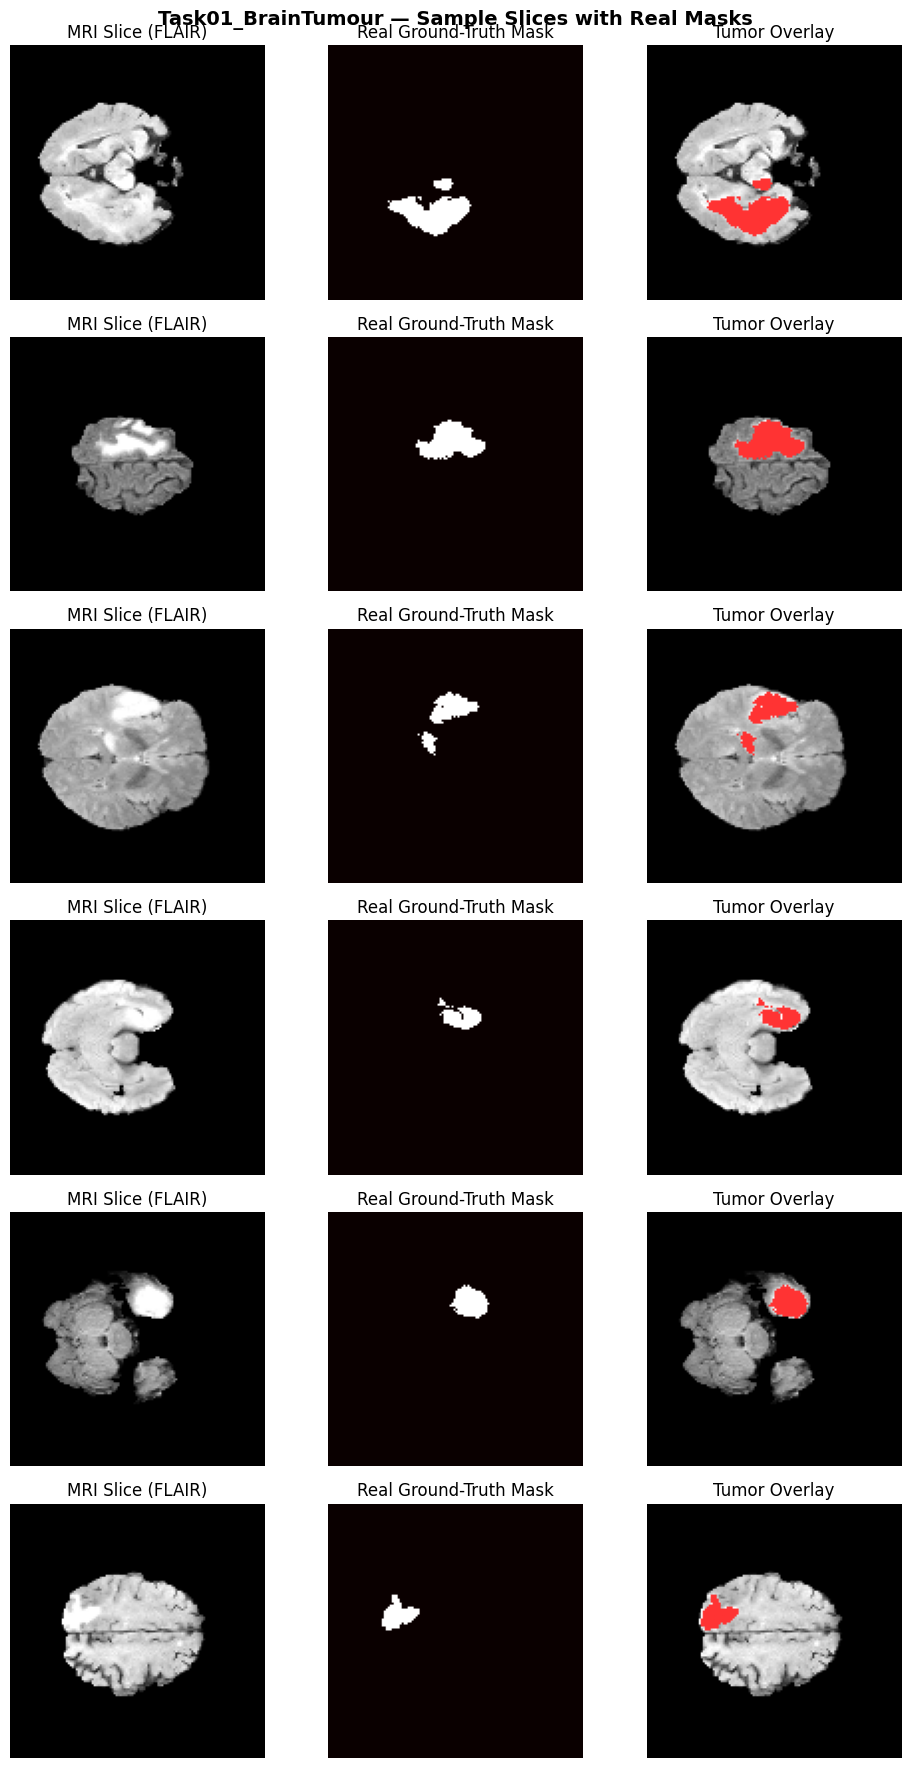

In [ ]:
# Show 6 random training slices with their REAL masks and overlay
np.random.seed(7)
sample_idx = np.random.randint(0, len(X_train_full), size=6)

fig, axes = plt.subplots(6, 3, figsize=(10, 18))
for row, idx in enumerate(sample_idx):
    img  = X_train_full[idx].squeeze()
    mask = y_train_full[idx].squeeze()
    overlay = np.stack([img, img, img], axis=-1)
    overlay[mask > 0.5] = [1, 0.2, 0.2]  # red overlay on tumor

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title('MRI Slice (FLAIR)')
    axes[row, 1].imshow(mask, cmap='hot')
    axes[row, 1].set_title('Real Ground-Truth Mask')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Tumor Overlay')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Task01_BrainTumour — Sample Slices with Real Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Shared Loss Functions & Evaluation Metrics

In [ ]:
# ── Dice Coefficient ──────────────────────────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# ── IoU ───────────────────────────────────────────────────────────────────────
def compute_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union        = np.logical_or(y_true, y_pred)
    union_sum    = np.sum(union)
    return 1.0 if union_sum == 0 else np.sum(intersection) / union_sum

# ── Full Evaluation ───────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """Returns metrics dict and binary predictions array."""
    preds     = model.predict(X_test, verbose=0)
    preds_bin = (preds > threshold).astype(np.uint8)

    dice_scores = []
    iou_scores  = []
    for i in range(len(X_test)):
        yt    = y_test[i].flatten()
        yp    = preds_bin[i].flatten()
        inter = np.sum(yt * yp)
        denom = np.sum(yt) + np.sum(yp)
        dice_scores.append((2 * inter) / (denom + 1e-8) if denom > 0 else 1.0)
        iou_scores.append(compute_iou(y_test[i], preds_bin[i]))

    yt_flat = y_test.flatten()
    yp_flat = preds_bin.flatten()
    cm      = confusion_matrix(yt_flat, yp_flat)
    tn, fp, fn, tp = cm.ravel()

    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    results = {
        "dice":      np.mean(dice_scores),
        "iou":       np.mean(iou_scores),
        "accuracy":  accuracy,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "cm":        cm
    }
    return results, preds_bin

print("Loss functions and evaluation helpers defined.")

Loss functions and evaluation helpers defined.


---
## 9. Model 1 — U-Net
Classic encoder–decoder architecture with skip connections.

In [ ]:
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D()(c3)

    # ── Bottleneck ───────────────────────────────────────────────────────────
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)
    b = layers.BatchNormalization()(b)
    b = layers.Dropout(0.3)(b)

    # ── Decoder ──────────────────────────────────────────────────────────────
    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4); u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64,  3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64,  3, activation='relu', padding='same')(c5)

    u3 = layers.UpSampling2D()(c5); u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(32,  3, activation='relu', padding='same')(u3)
    c6 = layers.Conv2D(32,  3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)
    return models.Model(inputs, outputs, name='UNet')

unet_model = build_unet((IMG_SIZE, IMG_SIZE, 1))
unet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss=bce_dice_loss, metrics=[dice_coef])
unet_model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 1,948,225 (7.43 MB)

 Trainable params: 1,947,265 (7.43 MB)

 Non-trainable params: 960 (3.75 KB)

### Train U-Net

In [ ]:
callbacks_unet = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                      monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

unet_history = unet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    callbacks=callbacks_unet
)

Epoch 1/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 79s 54ms/step - dice_coef: 0.8154 - loss: 0.2259 - val_dice_coef: 0.8638 - val_loss: 0.1624 - learning_rate: 1.0000e-04
Epoch 2/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - dice_coef: 0.8695 - loss: 0.1584 - val_dice_coef: 0.8793 - val_loss: 0.1454 - learning_rate: 1.0000e-04
Epoch 3/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - dice_coef: 0.8858 - loss: 0.1387 - val_dice_coef: 0.8812 - val_loss: 0.1439 - learning_rate: 1.0000e-04
Epoch 4/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - dice_coef: 0.8955 - loss: 0.1270 - val_dice_coef: 0.8860 - val_loss: 0.1378 - learning_rate: 1.0000e-04
Epoch 5/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - dice_coef: 0.9023 - loss: 0.1187 - val_dice_coef: 0.8523 - val_loss: 0.1794 - learning_rate: 1.0000e-04
Epoch 6/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - dice_coef: 0.9093 - loss: 0.1103 - val_dice_coef: 0.9053 - val_loss: 0.1156 - learning_rate: 1.0000e-04
Epoch 7/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 

### Evaluate U-Net

=== U-Net Results ===
  dice      : 0.9242
  iou       : 0.8639
  accuracy  : 0.9960
  precision : 0.9382
  recall    : 0.9339
  f1        : 0.9360


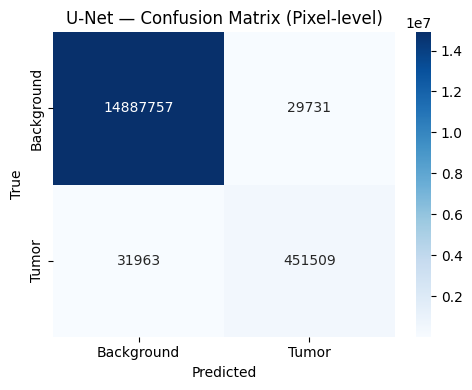

In [ ]:
unet_results, unet_preds = evaluate_model(unet_model, X_test, y_test)
print("=== U-Net Results ===")
for k, v in unet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(unet_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Tumor'],
            yticklabels=['Background', 'Tumor'])
plt.title('U-Net — Confusion Matrix (Pixel-level)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise U-Net Predictions

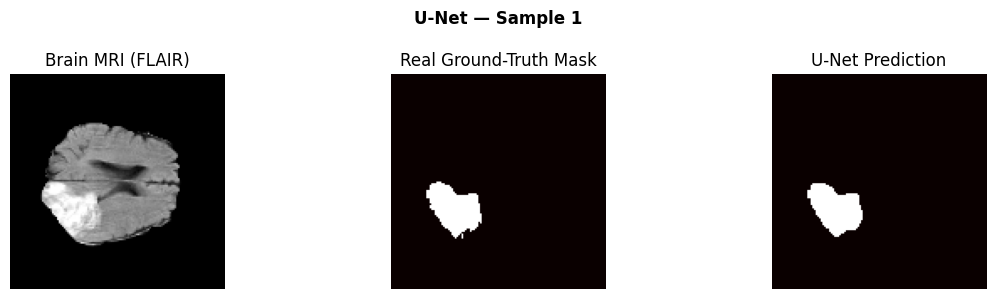

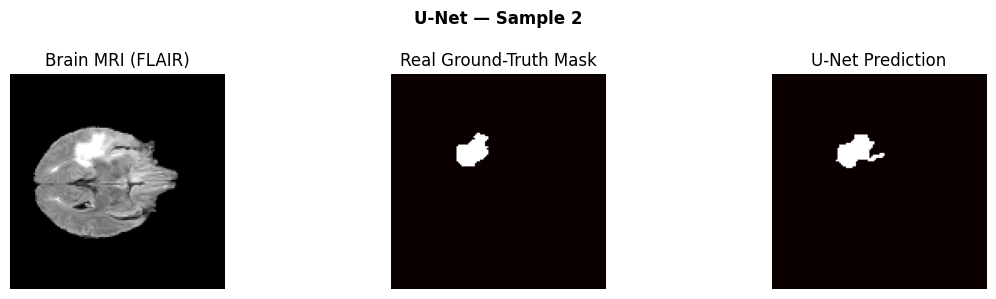

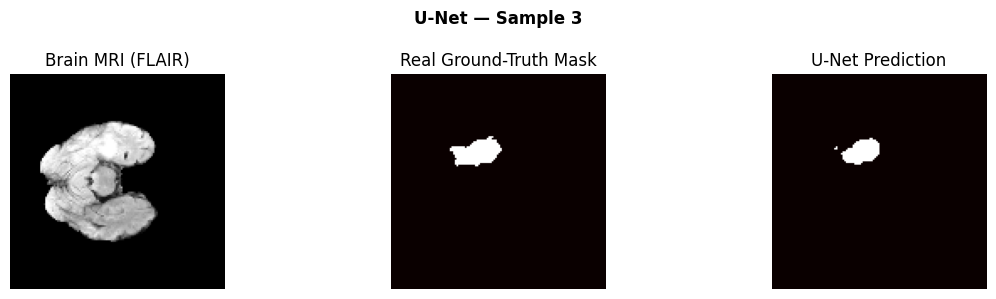

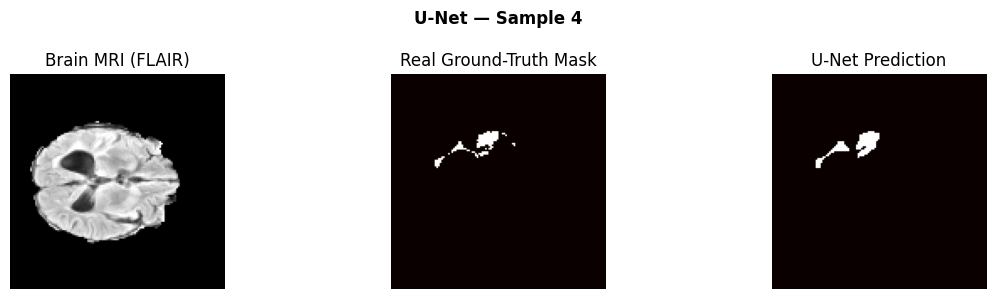

In [ ]:
np.random.seed(0)
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1); plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title('Brain MRI (FLAIR)'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(y_test[idx].squeeze(), cmap='hot')
    plt.title('Real Ground-Truth Mask'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(unet_preds[idx].squeeze(), cmap='hot')
    plt.title('U-Net Prediction'); plt.axis('off')
    plt.suptitle(f'U-Net — Sample {i+1}', fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 10. Model 2 — ResNet-UNet
U-Net decoder grafted onto a **ResNet-style encoder** with residual (identity shortcut) blocks.

In [ ]:
def resnet_block(x, filters):
    """Residual block: two conv layers + 1×1 shortcut to match channels."""
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_shape)

    c1 = resnet_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = resnet_block(p1,     64);  p2 = layers.MaxPooling2D()(c2)
    c3 = resnet_block(p2,    128);  p3 = layers.MaxPooling2D()(c3)

    b = resnet_block(p3, 256)
    b = layers.Dropout(0.3)(b)

    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    d1 = resnet_block(u1, 128)

    u2 = layers.UpSampling2D()(d1); u2 = layers.concatenate([u2, c2])
    d2 = resnet_block(u2, 64)

    u3 = layers.UpSampling2D()(d2); u3 = layers.concatenate([u3, c1])
    d3 = resnet_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)
    return models.Model(inputs, outputs, name='ResNet_UNet')


resnet_model = build_resnet_unet((IMG_SIZE, IMG_SIZE, 1))
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
resnet_model.summary()

Model: "ResNet_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │         64 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 2,063,009 (7.87 MB)

 Trainable params: 2,058,785 (7.85 MB)

 Non-trainable params: 4,224 (16.50 KB)

### Train ResNet-UNet

In [ ]:
callbacks_resnet = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                      monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

resnet_history = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    callbacks=callbacks_resnet
)

Epoch 1/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step - dice_coef: 0.7259 - loss: 0.3192 - val_dice_coef: 0.8088 - val_loss: 0.2227 - learning_rate: 1.0000e-04
Epoch 2/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - dice_coef: 0.8567 - loss: 0.1702 - val_dice_coef: 0.8684 - val_loss: 0.1558 - learning_rate: 1.0000e-04
Epoch 3/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - dice_coef: 0.8833 - loss: 0.1404 - val_dice_coef: 0.8864 - val_loss: 0.1371 - learning_rate: 1.0000e-04
Epoch 4/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - dice_coef: 0.8961 - loss: 0.1257 - val_dice_coef: 0.8944 - val_loss: 0.1271 - learning_rate: 1.0000e-04
Epoch 5/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - dice_coef: 0.9049 - loss: 0.1153 - val_dice_coef: 0.8870 - val_loss: 0.1381 - learning_rate: 1.0000e-04
Epoch 6/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - dice_coef: 0.9105 - loss: 0.1087 - val_dice_coef: 0.8963 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 7/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 

### Evaluate ResNet-UNet

=== ResNet-UNet Results ===
  dice      : 0.9212
  iou       : 0.8593
  accuracy  : 0.9959
  precision : 0.9428
  recall    : 0.9251
  f1        : 0.9339


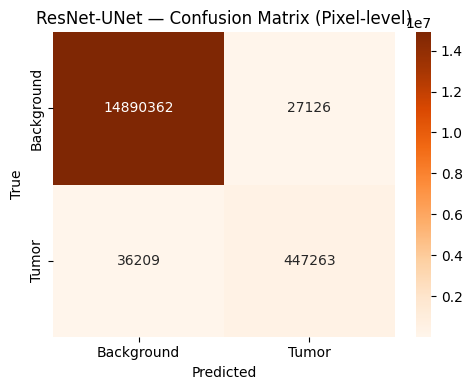

In [ ]:
resnet_results, resnet_preds = evaluate_model(resnet_model, X_test, y_test)
print("=== ResNet-UNet Results ===")
for k, v in resnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(resnet_results['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Background', 'Tumor'],
            yticklabels=['Background', 'Tumor'])
plt.title('ResNet-UNet — Confusion Matrix (Pixel-level)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise ResNet-UNet Predictions

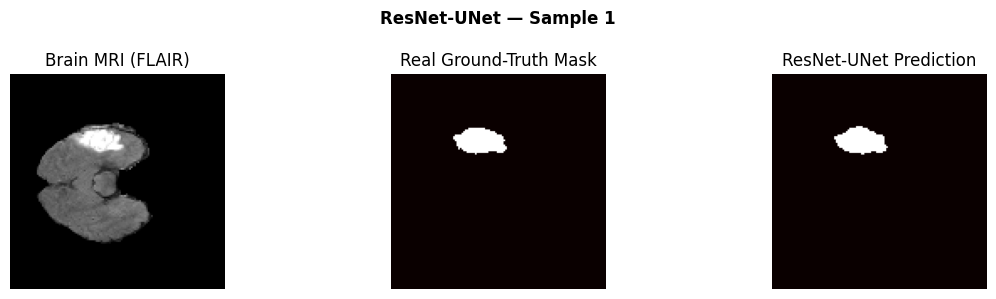

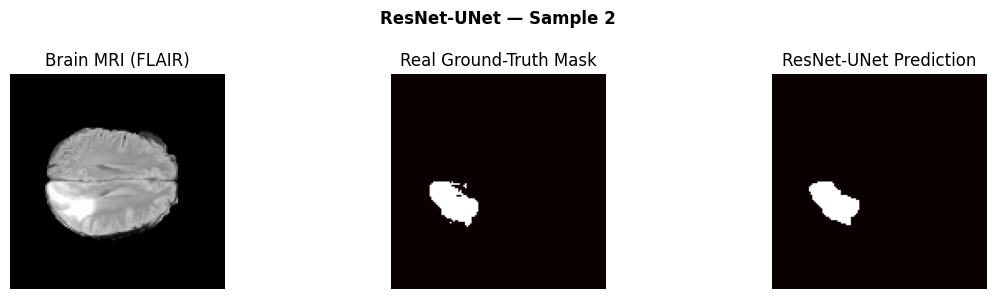

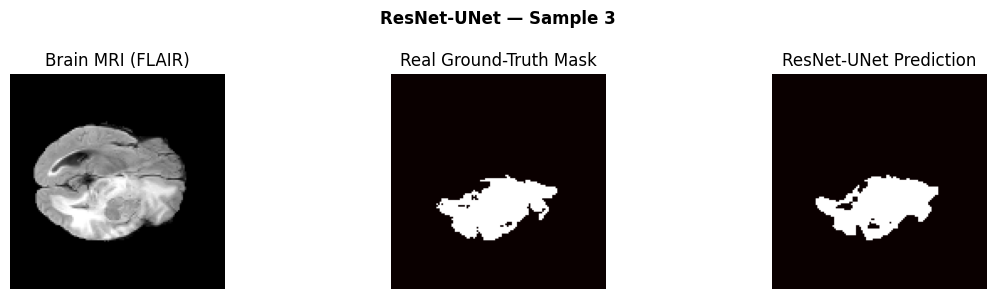

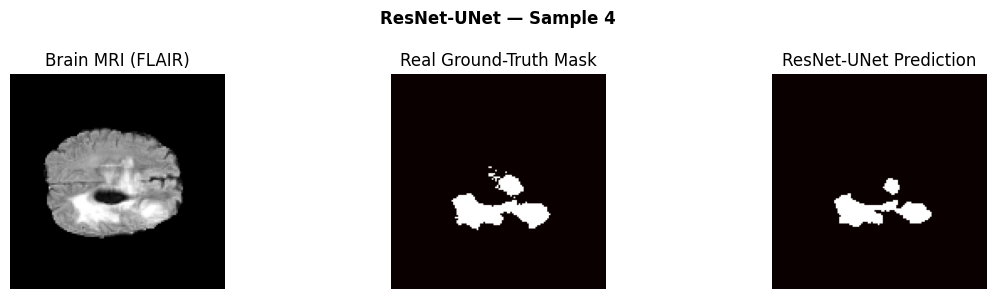

In [ ]:
np.random.seed(1)
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1); plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title('Brain MRI (FLAIR)'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(y_test[idx].squeeze(), cmap='hot')
    plt.title('Real Ground-Truth Mask'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(resnet_preds[idx].squeeze(), cmap='hot')
    plt.title('ResNet-UNet Prediction'); plt.axis('off')
    plt.suptitle(f'ResNet-UNet — Sample {i+1}', fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 11. Model 3 — SegNet
SegNet uses **pooling indices** concept. Approximated with UpSampling2D + Conv blocks.

In [ ]:
def build_segnet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_shape)

    # ── Encoder Block 1 ──────────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # ── Encoder Block 2 ──────────────────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # ── Encoder Block 3 ──────────────────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # ── Decoder Block 3 ──────────────────────────────────────────────────────
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── Decoder Block 2 ──────────────────────────────────────────────────────
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── Decoder Block 1 ──────────────────────────────────────────────────────
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='SegNet')


segnet_model = build_segnet((IMG_SIZE, IMG_SIZE, 1))
segnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
segnet_model.summary()

Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,884,993 (11.01 MB)

 Trainable params: 2,881,409 (10.99 MB)

 Non-trainable params: 3,584 (14.00 KB)

### Train SegNet

In [ ]:
callbacks_segnet = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                      monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

segnet_history = segnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    callbacks=callbacks_segnet
)

Epoch 1/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 129s 107ms/step - dice_coef: 0.2761 - loss: 1.0059 - val_dice_coef: 0.5748 - val_loss: 0.5403 - learning_rate: 1.0000e-04
Epoch 2/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 98s 80ms/step - dice_coef: 0.6876 - loss: 0.3901 - val_dice_coef: 0.7984 - val_loss: 0.2452 - learning_rate: 1.0000e-04
Epoch 3/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - dice_coef: 0.8325 - loss: 0.2077 - val_dice_coef: 0.8447 - val_loss: 0.1966 - learning_rate: 1.0000e-04
Epoch 4/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - dice_coef: 0.8685 - loss: 0.1618 - val_dice_coef: 0.8733 - val_loss: 0.1538 - learning_rate: 1.0000e-04
Epoch 5/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - dice_coef: 0.8860 - loss: 0.1399 - val_dice_coef: 0.8842 - val_loss: 0.1414 - learning_rate: 1.0000e-04
Epoch 6/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - dice_coef: 0.8951 - loss: 0.1287 - val_dice_coef: 0.8852 - val_loss: 0.1412 - learning_rate: 1.0000e-04
Epoch 7/30
951/951 ━━━━━━━━━━━━━━━━━━━

### Evaluate SegNet

=== SegNet Results ===
  dice      : 0.9182
  iou       : 0.8541
  accuracy  : 0.9956
  precision : 0.9354
  recall    : 0.9248
  f1        : 0.9301


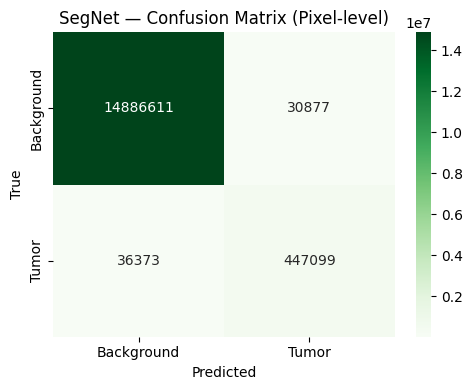

In [ ]:
segnet_results, segnet_preds = evaluate_model(segnet_model, X_test, y_test)
print("=== SegNet Results ===")
for k, v in segnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(segnet_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Background', 'Tumor'],
            yticklabels=['Background', 'Tumor'])
plt.title('SegNet — Confusion Matrix (Pixel-level)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise SegNet Predictions

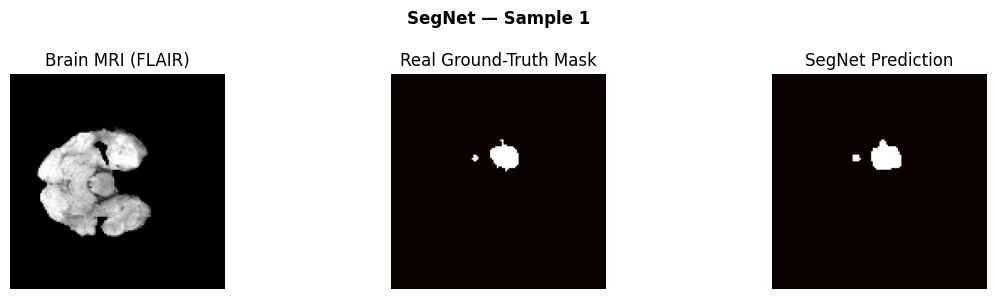

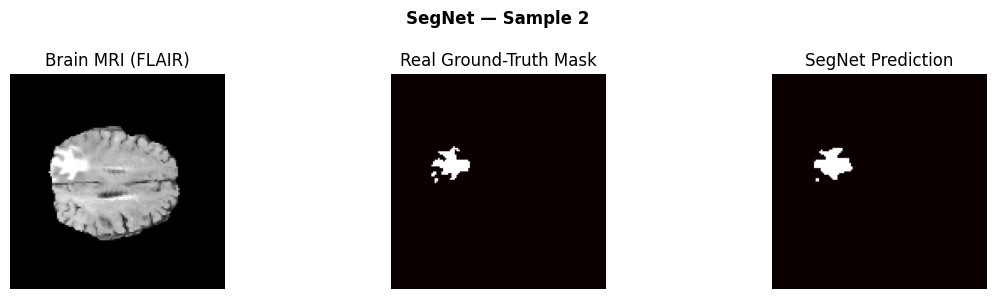

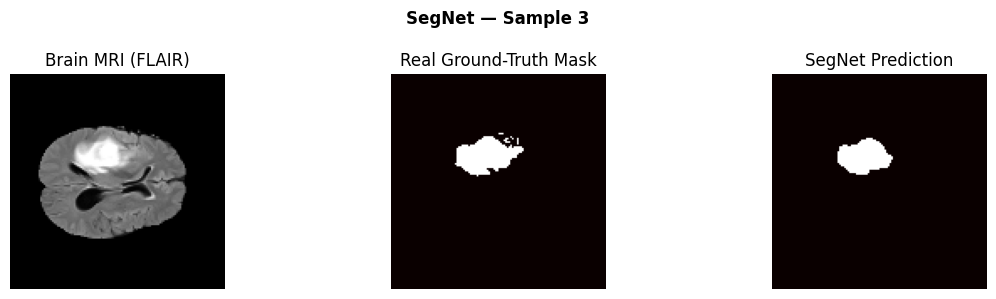

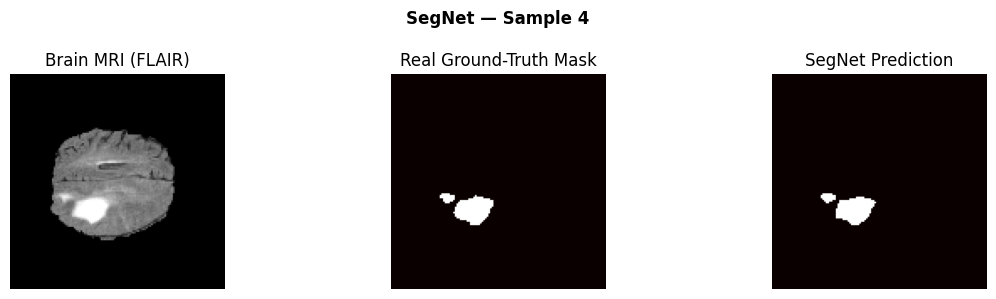

In [ ]:
np.random.seed(2)
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1); plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title('Brain MRI (FLAIR)'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(y_test[idx].squeeze(), cmap='hot')
    plt.title('Real Ground-Truth Mask'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(segnet_preds[idx].squeeze(), cmap='hot')
    plt.title('SegNet Prediction'); plt.axis('off')
    plt.suptitle(f'SegNet — Sample {i+1}', fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 12. Model 4 — DeepLabV3+ (Baseline) vs DeepLabV3+ with Transformer Attention

We train **two** DeepLabV3+ variants so the metric impact of attention is directly measurable:

| Variant | Key addition |
|---------|-------------|
| **DeepLabV3+ Baseline** | Original ASPP, no attention |
| **DeepLabV3+ + Attention** | SE Channel Attention + CBAM Spatial Attention + Transformer MHSA in ASPP |

Brain tumours are **irregular, multi-scale, and asymmetric** — ideal for attention mechanisms
that can learn to focus on small high-signal regions and suppress healthy tissue.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PART A — DeepLabV3+ BASELINE  (original, no attention)
# ══════════════════════════════════════════════════════════════════════════════

def aspp_block_baseline(x, filters=128, dilation_rates=(1, 6, 12)):
    """Original ASPP — no attention modules."""
    shape = x.shape
    branches = []
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, gap.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(shape[1], shape[2]), interpolation='bilinear')(gap)
    branches.append(gap)
    for rate in dilation_rates:
        branch = layers.Conv2D(filters, 3, padding='same',
                               dilation_rate=rate, activation='relu')(x)
        branch = layers.BatchNormalization()(branch)
        branches.append(branch)
    x = layers.concatenate(branches)
    x = layers.Conv2D(filters, 1, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def build_deeplabv3plus_baseline(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(32, 3, strides=1, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    low_level = x
    x = layers.Conv2D(64,  3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = aspp_block_baseline(x, filters=128, dilation_rates=(1, 6, 12))
    x = layers.UpSampling2D(size=(8, 8), interpolation='bilinear')(x)
    low_level = layers.Conv2D(32, 1, padding='same', activation='relu')(low_level)
    low_level = layers.BatchNormalization()(low_level)
    x = layers.concatenate([x, low_level])
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='DeepLabV3Plus_Baseline')


# ══════════════════════════════════════════════════════════════════════════════
# PART B — Attention Modules
# ══════════════════════════════════════════════════════════════════════════════

def channel_attention(x, reduction_ratio=16):
    """
    Squeeze-and-Excitation (SE) block.
    Suppresses healthy-tissue channels, amplifies tumour-signal channels.
    """
    C = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(C // reduction_ratio, 8), activation='relu')(se)
    se = layers.Dense(C, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, C))(se)
    return layers.Multiply()([x, se])

def spatial_attention(x):
    """
    CBAM Spatial Attention.
    Generates a 2-D saliency map — highlights tumour pixels,
    suppresses background brain tissue.
    """
    avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda t: tf.reduce_max(t,  axis=-1, keepdims=True))(x)
    concat   = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    attn_map = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)
    return layers.Multiply()([x, attn_map])

def transformer_attention_block(x, num_heads=4, key_dim=32):
    """
    Multi-Head Self-Attention (Transformer block).
    Applied at the ASPP bottleneck.
    Captures long-range dependencies across the feature map.
    """
    B, H, W, C = x.shape[0], x.shape[1], x.shape[2], x.shape[3]
    seq_len = H * W

    x_flat = layers.Reshape((seq_len, C))(x)

    x_norm  = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    attn    = layers.MultiHeadAttention(num_heads=num_heads,
                                        key_dim=key_dim, dropout=0.1)(x_norm, x_norm)
    x_flat  = layers.Add()([x_flat, attn])

    x_norm2 = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    ffn     = layers.Dense(C * 2, activation='gelu')(x_norm2)
    ffn     = layers.Dropout(0.1)(ffn)
    ffn     = layers.Dense(C)(ffn)
    x_flat  = layers.Add()([x_flat, ffn])

    return layers.Reshape((H, W, C))(x_flat)


# ══════════════════════════════════════════════════════════════════════════════
# PART C — ASPP + Attention (Transformer augmented)
# ══════════════════════════════════════════════════════════════════════════════

def aspp_attention_block(x, filters=128, dilation_rates=(1, 6, 12)):
    """
    ASPP with three-stage attention:
      1. Multi-scale dilated convolutions (original ASPP)
      2. SE Channel Attention — which feature channels matter?
      3. CBAM Spatial Attention — where in the image matters?
      4. Transformer MHSA — long-range context
    """
    shape = x.shape
    branches = []
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, gap.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(shape[1], shape[2]), interpolation='bilinear')(gap)
    branches.append(gap)
    for rate in dilation_rates:
        branch = layers.Conv2D(filters, 3, padding='same',
                               dilation_rate=rate, activation='relu')(x)
        branch = layers.BatchNormalization()(branch)
        branches.append(branch)
    out = layers.concatenate(branches)
    out = layers.Conv2D(filters, 1, padding='same', activation='relu')(out)
    out = layers.BatchNormalization()(out)

    out = channel_attention(out, reduction_ratio=16)
    out = spatial_attention(out)
    out = transformer_attention_block(out, num_heads=4, key_dim=32)
    return out


def build_deeplabv3plus_attention(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """
    DeepLabV3+ with full attention stack:
    SE + CBAM at each encoder stage, Transformer MHSA inside ASPP,
    SE + CBAM again in the decoder for tumour boundary refinement.
    """
    inputs = layers.Input(input_shape)

    x = layers.Conv2D(32, 3, strides=1, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)
    x = spatial_attention(x)
    low_level = x

    x = layers.Conv2D(64,  3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)
    x = spatial_attention(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)
    x = spatial_attention(x)

    x = layers.Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = aspp_attention_block(x, filters=128, dilation_rates=(1, 6, 12))

    x = layers.UpSampling2D(size=(8, 8), interpolation='bilinear')(x)
    low_level = layers.Conv2D(32, 1, padding='same', activation='relu')(low_level)
    low_level = layers.BatchNormalization()(low_level)
    x = layers.concatenate([x, low_level])
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='DeepLabV3Plus_Attention')


# ── Build both models ────────────────────────────────────────────────────────
deeplabv3_baseline = build_deeplabv3plus_baseline((IMG_SIZE, IMG_SIZE, 1))
deeplabv3_baseline.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                            loss=bce_dice_loss, metrics=[dice_coef])

deeplabv3_model = build_deeplabv3plus_attention((IMG_SIZE, IMG_SIZE, 1))
deeplabv3_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                         loss=bce_dice_loss, metrics=[dice_coef])

print("✅ DeepLabV3+ Baseline   —", deeplabv3_baseline.count_params(), "params")
print("✅ DeepLabV3+ + Attention —", deeplabv3_model.count_params(), "params")
deeplabv3_model.summary()

✅ DeepLabV3+ Baseline   — 1635745 params
✅ DeepLabV3+ + Attention — 1776920 params


Model: "DeepLabV3Plus_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128, 128,  │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 2)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 128, 128,  │         99 │ concatenate_8[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 128,  │          0 │ multiply[0][0],   │
│ (Multiply)          │ 32)               │            │ conv2d_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 64, 64,    │     18,496 │ multiply_1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        576 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,776,920 (6.78 MB)

 Trainable params: 1,774,488 (6.77 MB)

 Non-trainable params: 2,432 (9.50 KB)

### Train DeepLabV3+

In [ ]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                          monitor='val_dice_coef', mode='max'),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]

# ── Train Baseline ───────────────────────────────────────────────────────────
print("\n🚀 Training DeepLabV3+ Baseline...")
baseline_history = deeplabv3_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=8,
    callbacks=make_callbacks()
)

# ── Train Attention model ────────────────────────────────────────────────────
print("\n🚀 Training DeepLabV3+ + Transformer Attention...")
attention_history = deeplabv3_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=8,
    callbacks=make_callbacks()
)

deeplabv3_history = attention_history
print("\n✅ Both variants trained.")


🚀 Training DeepLabV3+ Baseline...
Epoch 1/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 113s 96ms/step - dice_coef: 0.2574 - loss: 1.0369 - val_dice_coef: 0.4402 - val_loss: 0.6406 - learning_rate: 1.0000e-04
Epoch 2/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - dice_coef: 0.6783 - loss: 0.3957 - val_dice_coef: 0.7847 - val_loss: 0.2540 - learning_rate: 1.0000e-04
Epoch 3/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - dice_coef: 0.8388 - loss: 0.1999 - val_dice_coef: 0.8602 - val_loss: 0.1807 - learning_rate: 1.0000e-04
Epoch 4/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - dice_coef: 0.8781 - loss: 0.1502 - val_dice_coef: 0.8734 - val_loss: 0.1543 - learning_rate: 1.0000e-04
Epoch 5/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - dice_coef: 0.8938 - loss: 0.1308 - val_dice_coef: 0.8851 - val_loss: 0.1479 - learning_rate: 1.0000e-04
Epoch 6/30
951/951 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - dice_coef: 0.9032 - loss: 0.1186 - val_dice_coef: 0.8939 - val_loss: 0.1302 - learning_rate: 1.0000e-04
Epoc

### Evaluate DeepLabV3+


=== DeepLabV3+ Baseline ===
  dice      : 0.9201
  iou       : 0.8571
  accuracy  : 0.9957
  precision : 0.9376
  recall    : 0.9263
  f1        : 0.9319

=== DeepLabV3+ + Attention ===
  dice      : 0.9194
  iou       : 0.8559
  accuracy  : 0.9957
  precision : 0.9317
  recall    : 0.9317
  f1        : 0.9317

=== Δ Improvement (Attention − Baseline) ===
  dice      : ▼ 0.0007
  iou       : ▼ 0.0013
  accuracy  : ▼ 0.0000
  precision : ▼ 0.0059
  recall    : ▲ 0.0054
  f1        : ▼ 0.0002


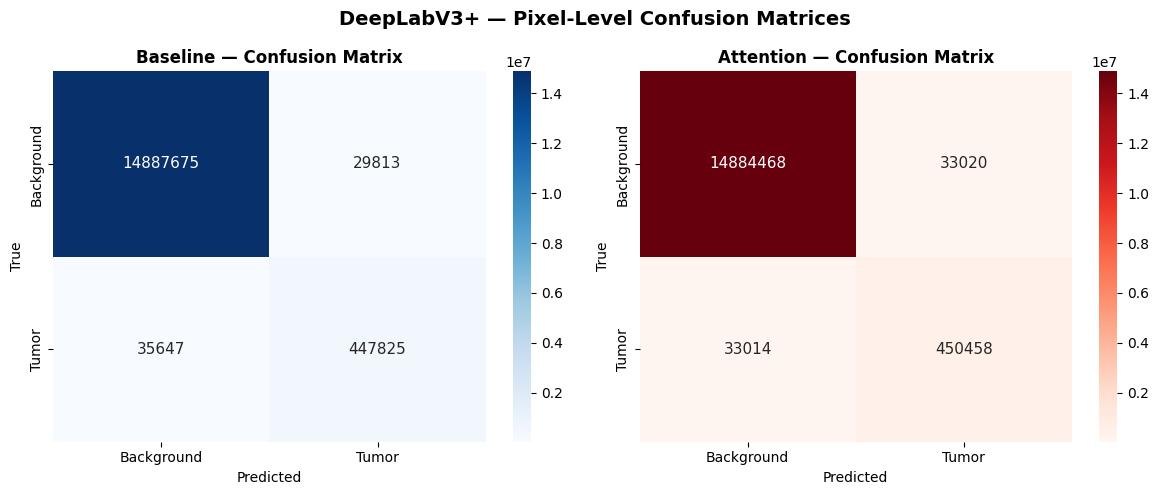

In [ ]:
baseline_results,  baseline_preds  = evaluate_model(deeplabv3_baseline, X_test, y_test)
attention_results, attention_preds = evaluate_model(deeplabv3_model,    X_test, y_test)
deeplabv3_results  = attention_results
deeplabv3_preds    = attention_preds

metrics_keys = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']

print("\n=== DeepLabV3+ Baseline ===")
for k in metrics_keys:
    print(f"  {k:10s}: {baseline_results[k]:.4f}")

print("\n=== DeepLabV3+ + Attention ===")
for k in metrics_keys:
    print(f"  {k:10s}: {attention_results[k]:.4f}")

print("\n=== Δ Improvement (Attention − Baseline) ===")
for k in metrics_keys:
    d = attention_results[k] - baseline_results[k]
    print(f"  {k:10s}: {'▲' if d>=0 else '▼'} {abs(d):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title, cmap in zip(
        axes,
        [baseline_results, attention_results],
        ['Baseline — Confusion Matrix', 'Attention — Confusion Matrix'],
        ['Blues', 'Reds']):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Background', 'Tumor'],
                yticklabels=['Background', 'Tumor'],
                annot_kws={'size': 11})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('DeepLabV3+ — Pixel-Level Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Visualise DeepLabV3+ Predictions

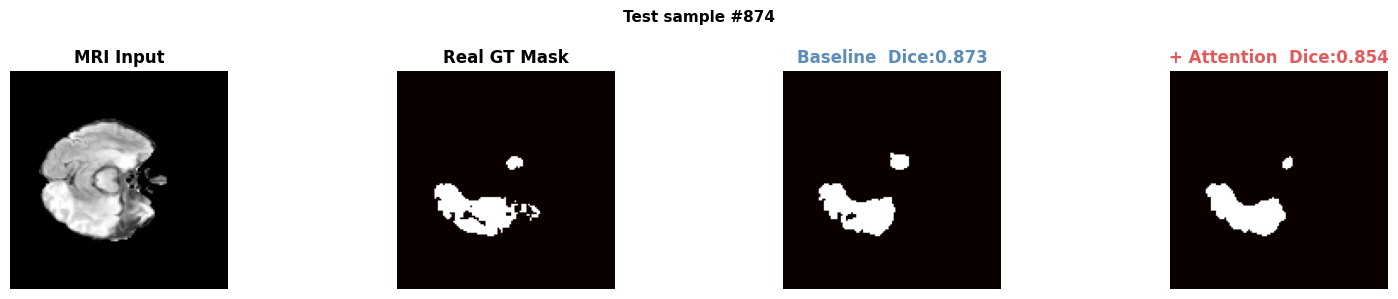

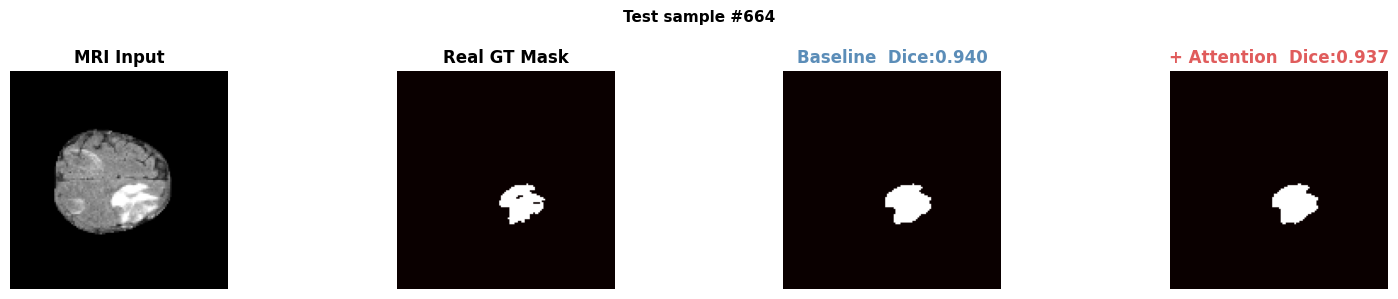

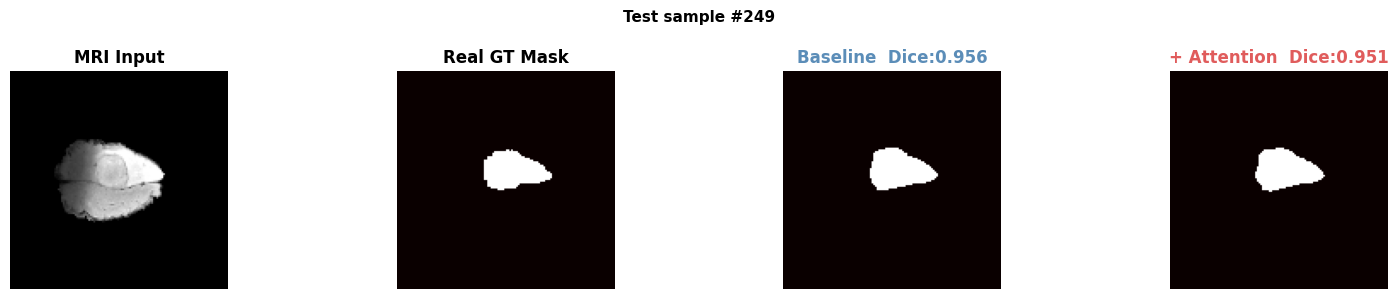

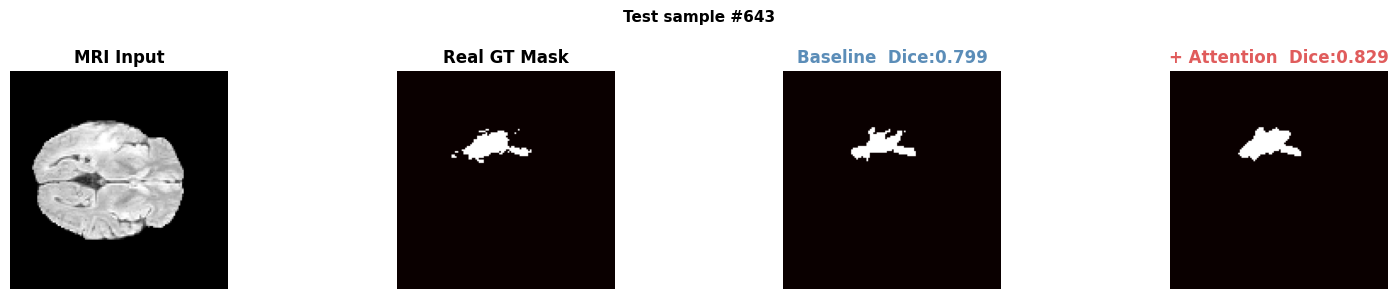

In [ ]:
np.random.seed(3)
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    axes[0].imshow(X_test[idx].squeeze(), cmap="gray")
    axes[0].set_title("MRI Input", fontweight="bold"); axes[0].axis("off")
    axes[1].imshow(y_test[idx].squeeze(), cmap="hot")
    axes[1].set_title("Real GT Mask", fontweight="bold"); axes[1].axis("off")
    axes[2].imshow(baseline_preds[idx].squeeze(), cmap="hot")
    yt = y_test[idx].flatten(); yb = baseline_preds[idx].flatten()
    db = (2*np.sum(yt*yb))/(np.sum(yt)+np.sum(yb)+1e-8)
    axes[2].set_title(f"Baseline  Dice:{db:.3f}", fontweight="bold", color="#5B8DB8"); axes[2].axis("off")
    axes[3].imshow(attention_preds[idx].squeeze(), cmap="hot")
    ya = attention_preds[idx].flatten()
    da = (2*np.sum(yt*ya))/(np.sum(yt)+np.sum(ya)+1e-8)
    axes[3].set_title(f"+ Attention  Dice:{da:.3f}", fontweight="bold", color="#E05C5C"); axes[3].axis("off")
    plt.suptitle(f"Test sample #{idx}", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()

---
## 12a. 📊 Attention Impact — Full Visualization Suite
Six plots: grouped bars, delta chart, radar, training curves, prediction grid, confusion matrices.

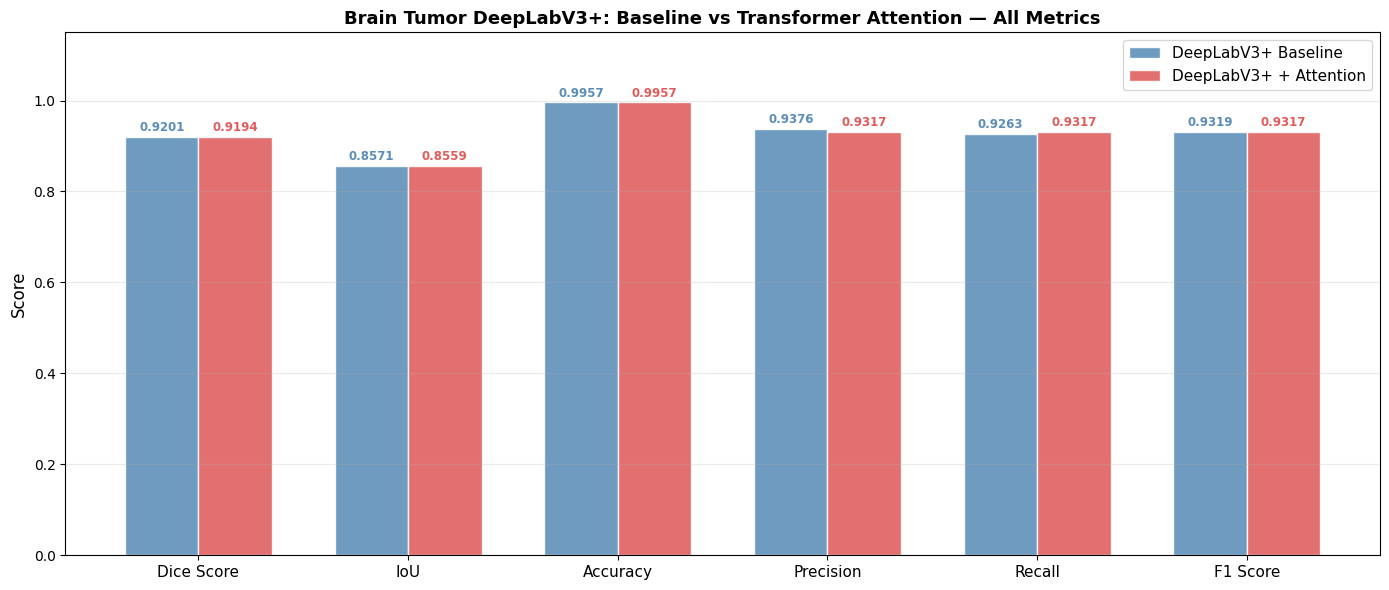

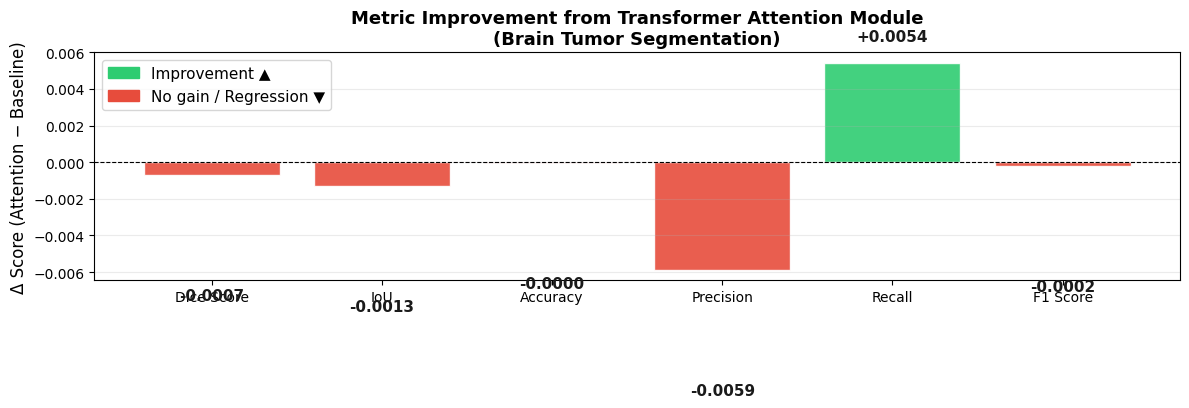

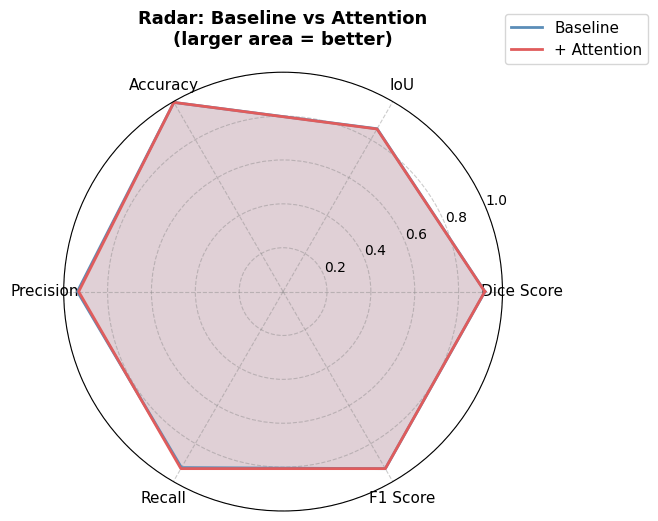

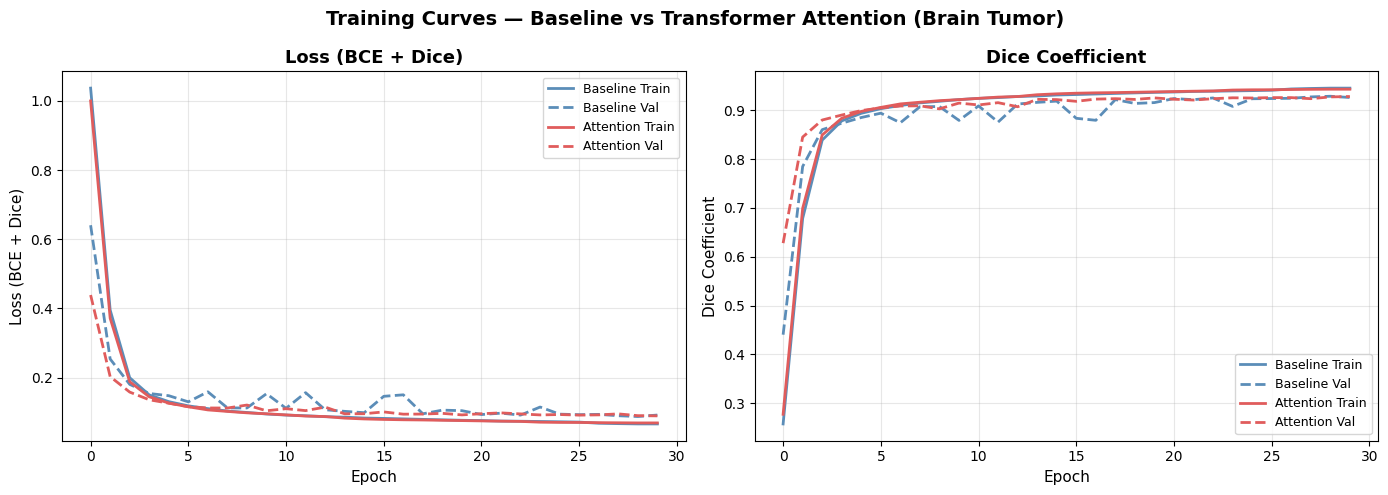

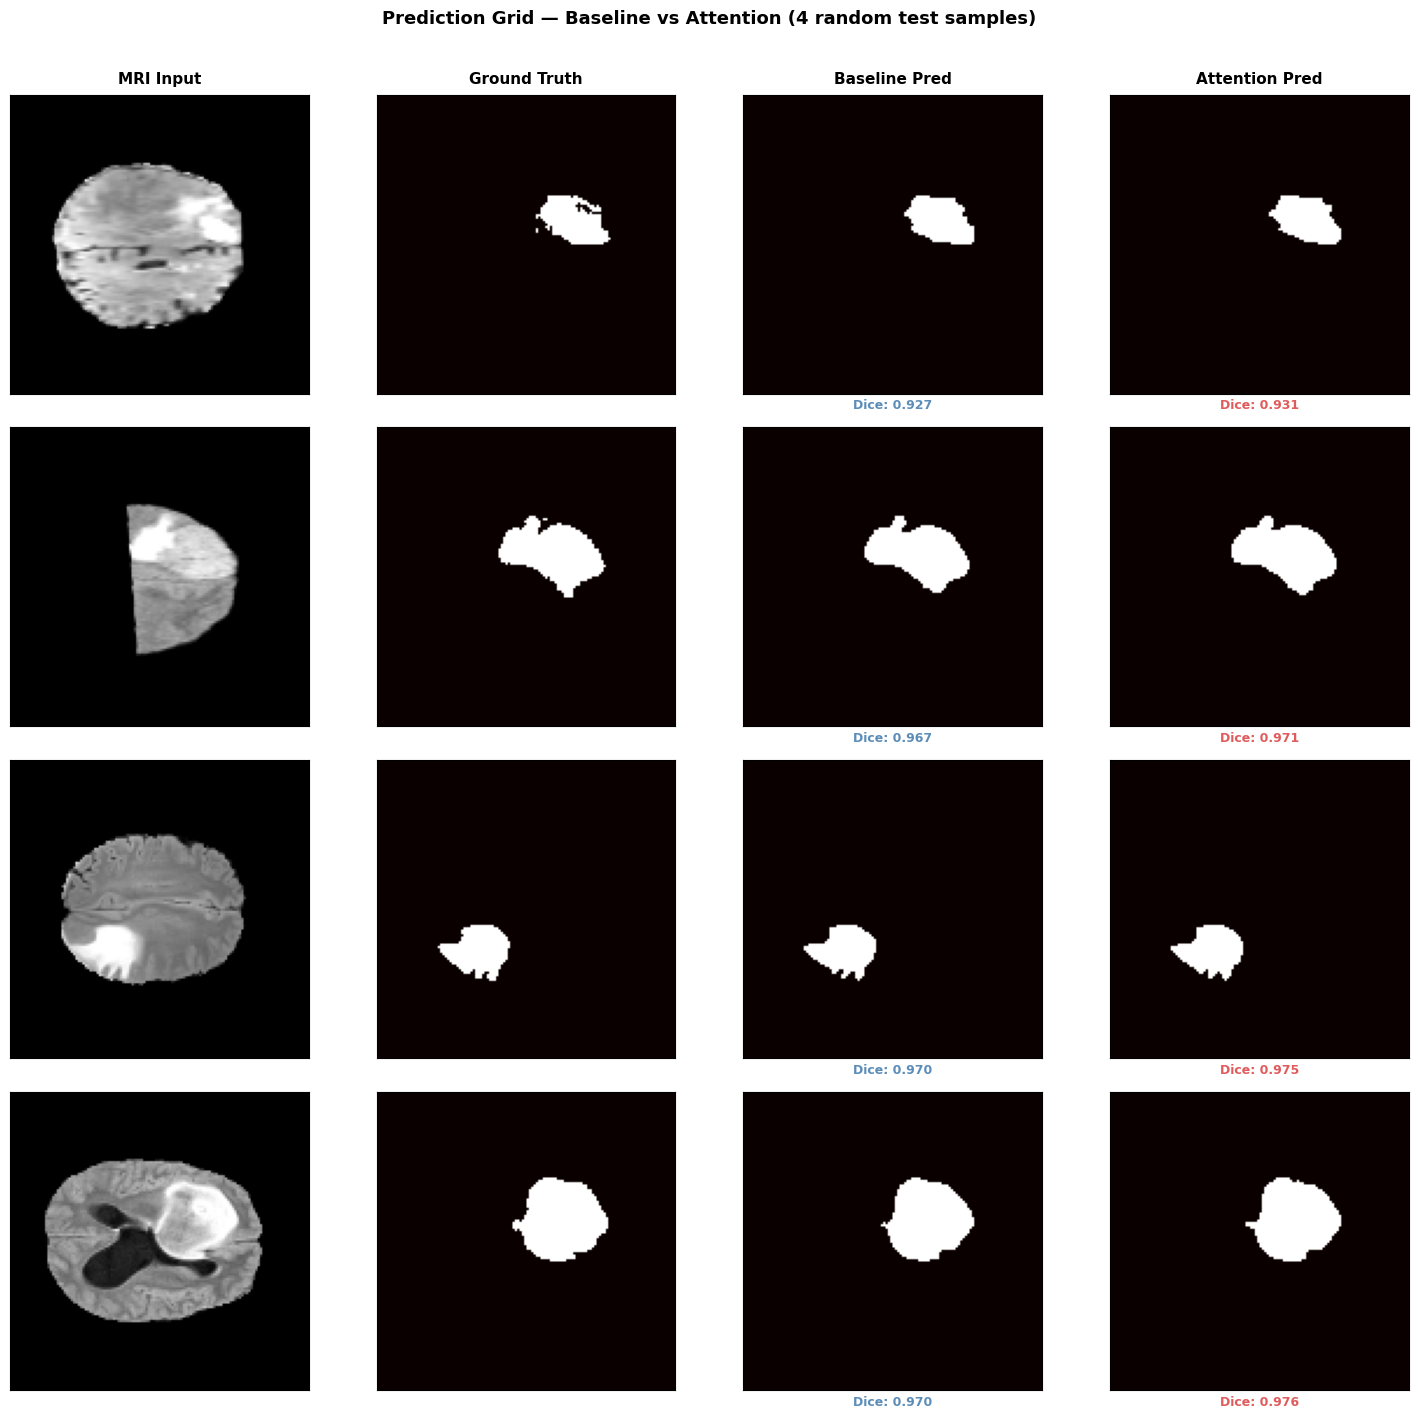

In [ ]:
import matplotlib.patches as mpatches

metrics_keys   = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']
metrics_labels = ['Dice Score', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

bl_vals  = [baseline_results[m]  for m in metrics_keys]
att_vals = [attention_results[m] for m in metrics_keys]
deltas   = [a - b for a, b in zip(att_vals, bl_vals)]

BL_COLOR  = '#5B8DB8'
ATT_COLOR = '#E05C5C'
POS_COLOR = '#2ECC71'
NEG_COLOR = '#E74C3C'

# ── PLOT 1: Grouped bar — all metrics ────────────────────────────────────────
x     = np.arange(len(metrics_keys))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, bl_vals,  width, label='DeepLabV3+ Baseline',   color=BL_COLOR,  alpha=0.88, edgecolor='white')
b2 = ax.bar(x + width/2, att_vals, width, label='DeepLabV3+ + Attention', color=ATT_COLOR, alpha=0.88, edgecolor='white')
for bar, v in zip(b1, bl_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006, f'{v:.4f}',
            ha='center', va='bottom', fontsize=8.5, color=BL_COLOR, fontweight='bold')
for bar, v in zip(b2, att_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006, f'{v:.4f}',
            ha='center', va='bottom', fontsize=8.5, color=ATT_COLOR, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Brain Tumor DeepLabV3+: Baseline vs Transformer Attention — All Metrics',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('brain_deeplabv3_baseline_vs_attention.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 2: Delta bar ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
bar_cols = [POS_COLOR if d >= 0 else NEG_COLOR for d in deltas]
bars = ax.bar(metrics_labels, deltas, color=bar_cols, edgecolor='white', alpha=0.9)
for bar, d in zip(bars, deltas):
    ypos = bar.get_height() + 0.001 if d >= 0 else bar.get_height() - 0.007
    ax.text(bar.get_x()+bar.get_width()/2, ypos, f'{d:+.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1a1a1a')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Δ Score (Attention − Baseline)', fontsize=12)
ax.set_title('Metric Improvement from Transformer Attention Module\n(Brain Tumor Segmentation)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.legend(handles=[mpatches.Patch(color=POS_COLOR, label='Improvement ▲'),
                   mpatches.Patch(color=NEG_COLOR, label='No gain / Regression ▼')],
          fontsize=11)
plt.tight_layout()
plt.savefig('brain_deeplabv3_delta.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 3: Radar chart ───────────────────────────────────────────────────────
N      = len(metrics_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
bv     = bl_vals  + bl_vals[:1]
av     = att_vals + att_vals[:1]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, bv,  color=BL_COLOR,  linewidth=2, label='Baseline')
ax.fill(angles, bv,  color=BL_COLOR,  alpha=0.18)
ax.plot(angles, av,  color=ATT_COLOR, linewidth=2, label='+ Attention')
ax.fill(angles, av,  color=ATT_COLOR, alpha=0.18)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Radar: Baseline vs Attention\n(larger area = better)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='grey', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('brain_deeplabv3_radar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 4: Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in zip(axes,
                           ['loss', 'dice_coef'],
                           ['Loss (BCE + Dice)', 'Dice Coefficient']):
    ax.plot(baseline_history.history[key],         color=BL_COLOR,  lw=2, label='Baseline Train')
    ax.plot(baseline_history.history[f'val_{key}'],color=BL_COLOR,  lw=2, ls='--', label='Baseline Val')
    ax.plot(attention_history.history[key],         color=ATT_COLOR, lw=2, label='Attention Train')
    ax.plot(attention_history.history[f'val_{key}'],color=ATT_COLOR, lw=2, ls='--', label='Attention Val')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Training Curves — Baseline vs Transformer Attention (Brain Tumor)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('brain_deeplabv3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 5: Prediction grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(15, 14))
for col, title in enumerate(['MRI Input','Ground Truth','Baseline Pred','Attention Pred']):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)
for row in range(4):
    idx = np.random.randint(0, len(X_test))
    axes[row,0].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[row,1].imshow(y_test[idx].squeeze(), cmap='hot')
    axes[row,2].imshow(baseline_preds[idx].squeeze(),  cmap='hot')
    axes[row,3].imshow(attention_preds[idx].squeeze(), cmap='hot')
    yt = y_test[idx].flatten()
    for col, yp in enumerate([baseline_preds[idx].flatten(), attention_preds[idx].flatten()], 2):
        d = (2*np.sum(yt*yp))/(np.sum(yt)+np.sum(yp)+1e-8)
        c = BL_COLOR if col==2 else ATT_COLOR
        axes[row,col].set_xlabel(f'Dice: {d:.3f}', fontsize=9, color=c, fontweight='bold')
    for col in range(4):
        axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
plt.suptitle('Prediction Grid — Baseline vs Attention (4 random test samples)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('brain_deeplabv3_prediction_grid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. 📊 Model Comparison — Bar Graphs
Side-by-side comparison of all five models across Dice Score, IoU, Accuracy, Precision, Recall, and F1 Score.

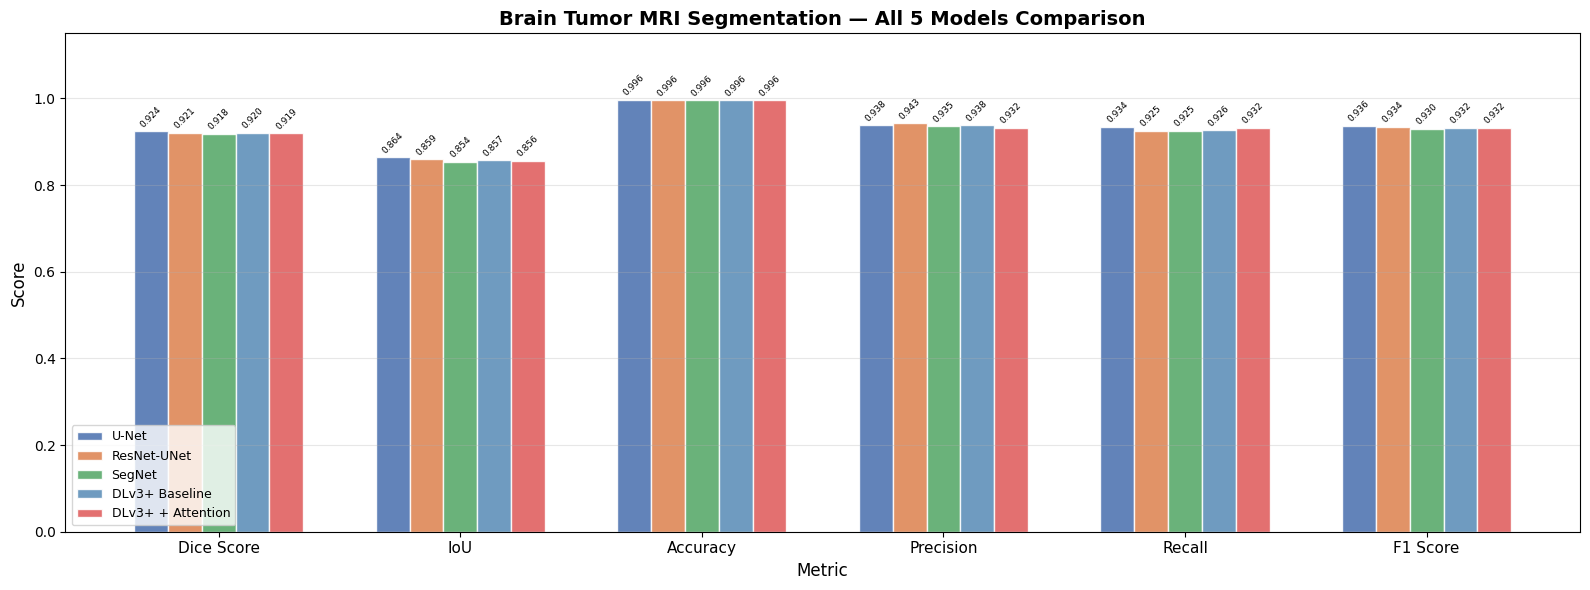

In [ ]:
# ── Collect results — 5 models ───────────────────────────────────────────────
all_results = {
    'U-Net':               unet_results,
    'ResNet-UNet':         resnet_results,
    'SegNet':              segnet_results,
    'DLv3+ Baseline':      baseline_results,
    'DLv3+ + Attention':   attention_results,
}

model_names   = list(all_results.keys())
metrics       = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Dice Score', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
colors        = ['#4C72B0', '#DD8452', '#55A868', '#5B8DB8', '#E05C5C']

# ── Grouped bar chart (5 models) ─────────────────────────────────────────────
x     = np.arange(len(metrics))
width = 0.14
fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=45)
ax.set_xlabel('Metric', fontsize=12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Brain Tumor MRI Segmentation — All 5 Models Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('brain_model_comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_696/3372180879.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=10, fontsize=10)
/tmp/ipykernel_696/3372180879.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=10, fontsize=10)


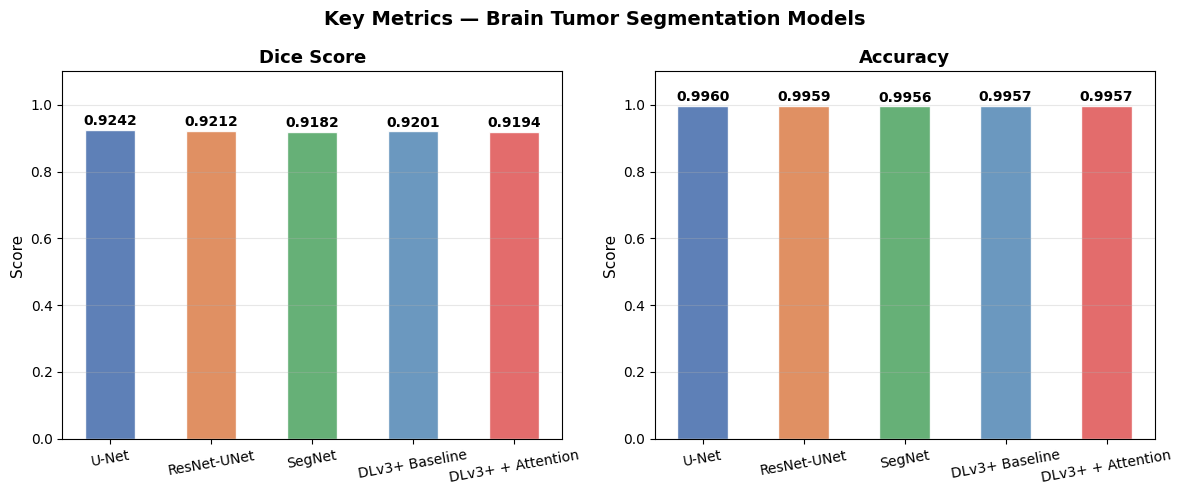

In [ ]:
# ── Dice Score & Accuracy Side-by-Side Highlight ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(axes,
                              ['dice', 'accuracy'],
                              ['Dice Score', 'Accuracy']):
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.9,
                  edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(model_names, rotation=10, fontsize=10)

plt.suptitle('Key Metrics — Brain Tumor Segmentation Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('brain_dice_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

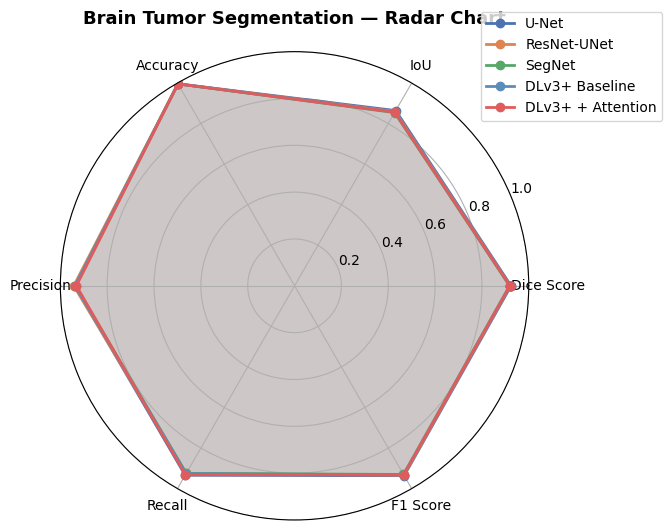

In [ ]:
# ── Radar / Spider Chart ──────────────────────────────────────────────────────
labels  = metric_labels
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (name, res) in enumerate(all_results.items()):
    vals   = [res[m] for m in metrics]
    vals  += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=colors[i])
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Brain Tumor Segmentation — Radar Chart',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('brain_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Summary Table & Best Model

In [ ]:
rows = []
for name, res in all_results.items():
    rows.append({
        'Model':     name,
        'Dice':      round(res['dice'],      4),
        'IoU':       round(res['iou'],       4),
        'Accuracy':  round(res['accuracy'],  4),
        'Precision': round(res['precision'], 4),
        'Recall':    round(res['recall'],    4),
        'F1':        round(res['f1'],        4),
    })

df = pd.DataFrame(rows).set_index('Model')

print("\n" + "="*65)
print("        Brain Tumor Segmentation — Results Summary")
print("="*65)
print(df.to_string())
print("="*65)

best_dice = max(all_results, key=lambda m: all_results[m]['dice'])
best_acc  = max(all_results, key=lambda m: all_results[m]['accuracy'])
best_iou  = max(all_results, key=lambda m: all_results[m]['iou'])
best_f1   = max(all_results, key=lambda m: all_results[m]['f1'])

print(f"\n🏆 Best by Dice Score : {best_dice}  ({all_results[best_dice]['dice']:.4f})")
print(f"🏆 Best by Accuracy   : {best_acc}  ({all_results[best_acc]['accuracy']:.4f})")
print(f"🏆 Best by IoU        : {best_iou}  ({all_results[best_iou]['iou']:.4f})")
print(f"🏆 Best by F1 Score   : {best_f1}  ({all_results[best_f1]['f1']:.4f})")


        Brain Tumor Segmentation — Results Summary
                     Dice     IoU  Accuracy  Precision  Recall      F1
Model                                                                 
U-Net              0.9242  0.8639    0.9960     0.9382  0.9339  0.9360
ResNet-UNet        0.9212  0.8593    0.9959     0.9428  0.9251  0.9339
SegNet             0.9182  0.8541    0.9956     0.9354  0.9248  0.9301
DLv3+ Baseline     0.9201  0.8571    0.9957     0.9376  0.9263  0.9319
DLv3+ + Attention  0.9194  0.8559    0.9957     0.9317  0.9317  0.9317

🏆 Best by Dice Score : U-Net  (0.9242)
🏆 Best by Accuracy   : U-Net  (0.9960)
🏆 Best by IoU        : U-Net  (0.8639)
🏆 Best by F1 Score   : U-Net  (0.9360)


## 15. Training Curves Comparison

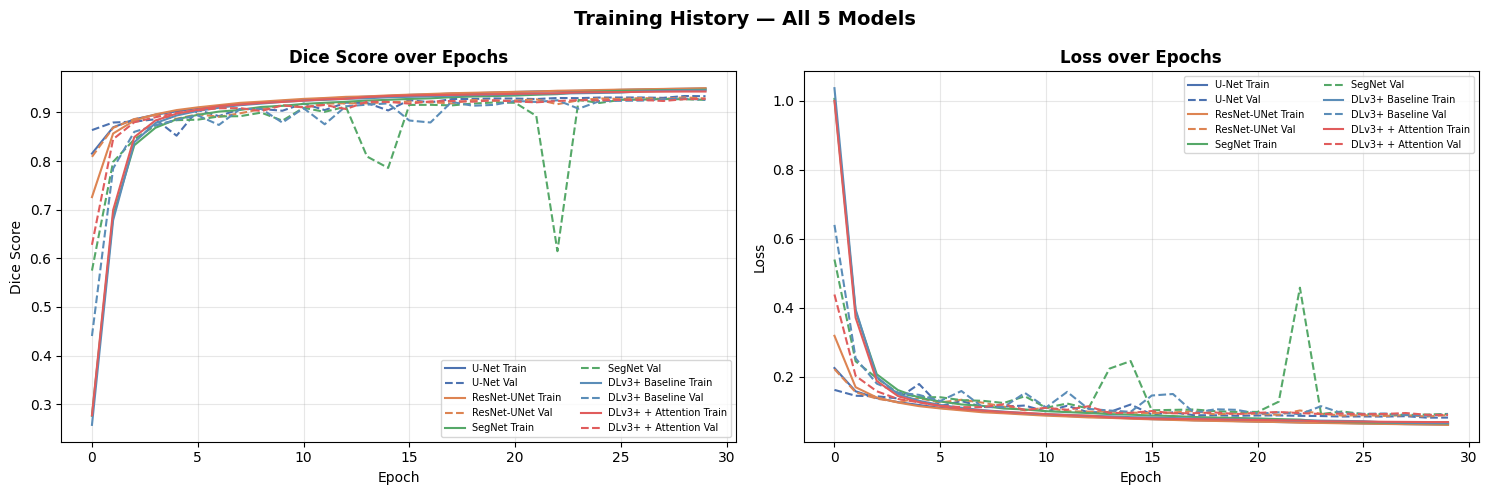

In [ ]:
histories = {
    'U-Net':               unet_history,
    'ResNet-UNet':         resnet_history,
    'SegNet':              segnet_history,
    'DLv3+ Baseline':      baseline_history,
    'DLv3+ + Attention':   attention_history,
}
colors_hist = ['#4C72B0', '#DD8452', '#55A868', '#5B8DB8', '#E05C5C']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, (name, hist) in enumerate(histories.items()):
    axes[0].plot(hist.history['dice_coef'],     label=f'{name} Train', color=colors_hist[i], linestyle='-')
    axes[0].plot(hist.history['val_dice_coef'], label=f'{name} Val',   color=colors_hist[i], linestyle='--')
    axes[1].plot(hist.history['loss'],          label=f'{name} Train', color=colors_hist[i], linestyle='-')
    axes[1].plot(hist.history['val_loss'],      label=f'{name} Val',   color=colors_hist[i], linestyle='--')
axes[0].set_title('Dice Score over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Dice Score')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)
axes[1].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
plt.suptitle('Training History — All 5 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('brain_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Side-by-Side Visual Comparison of All Models

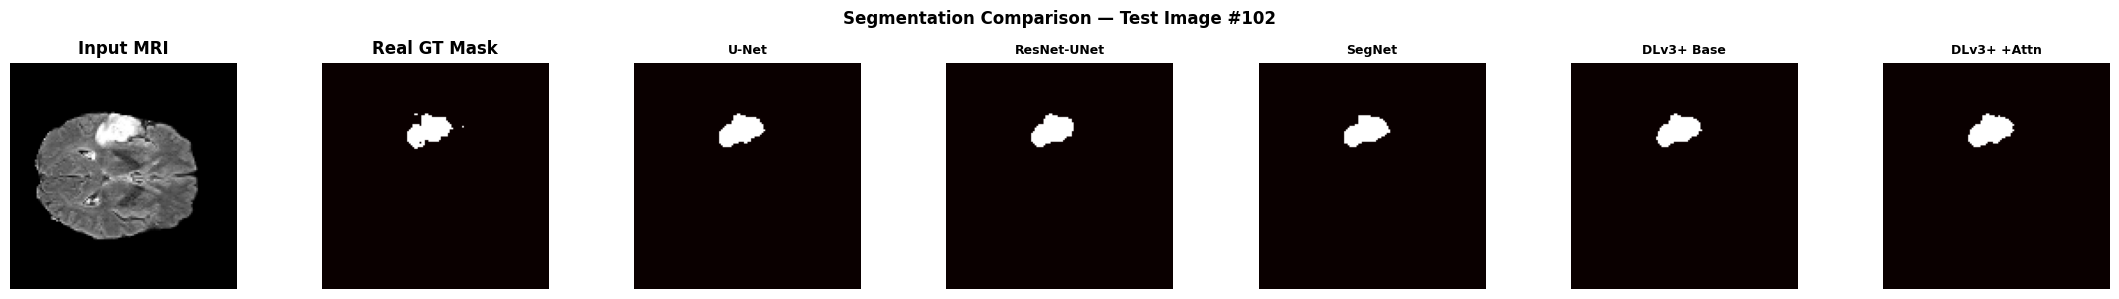

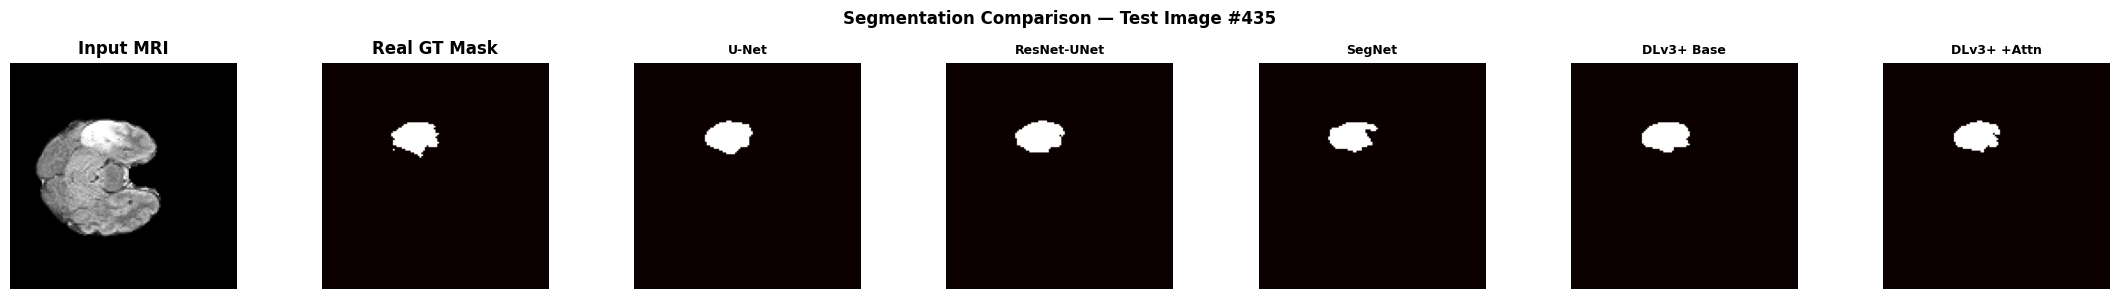

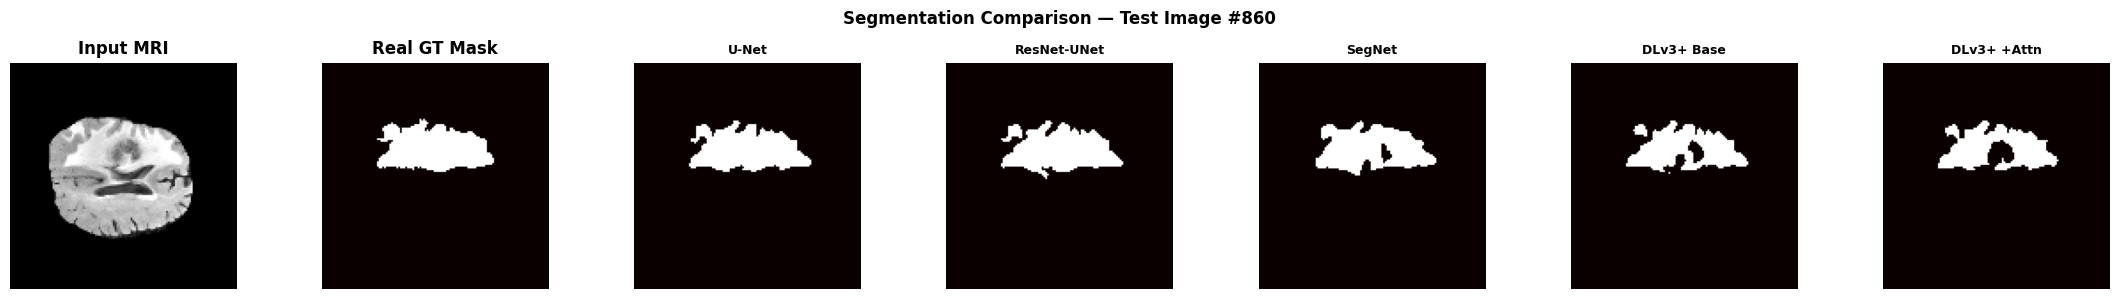

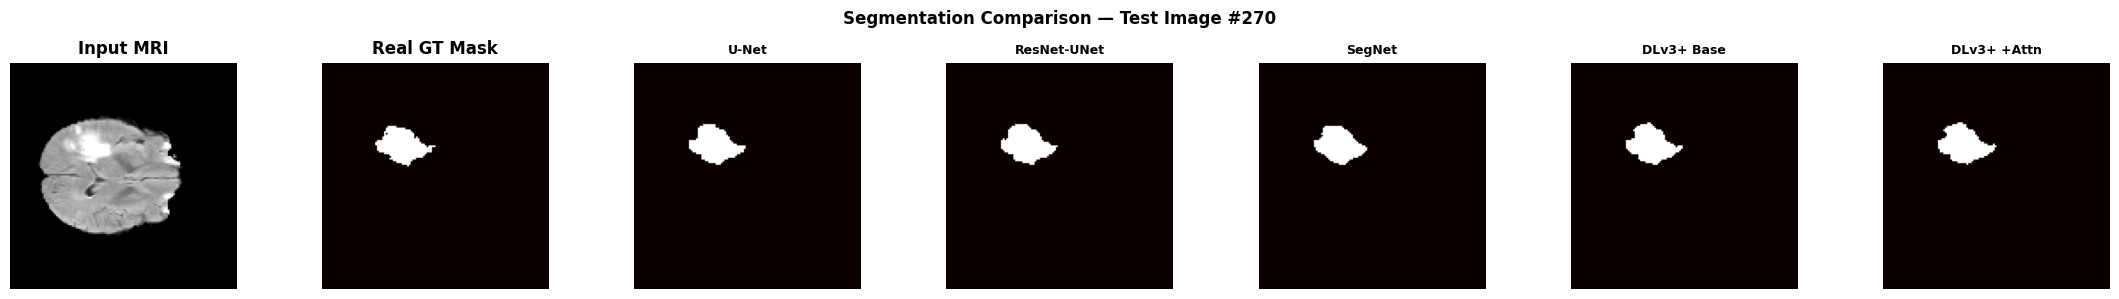

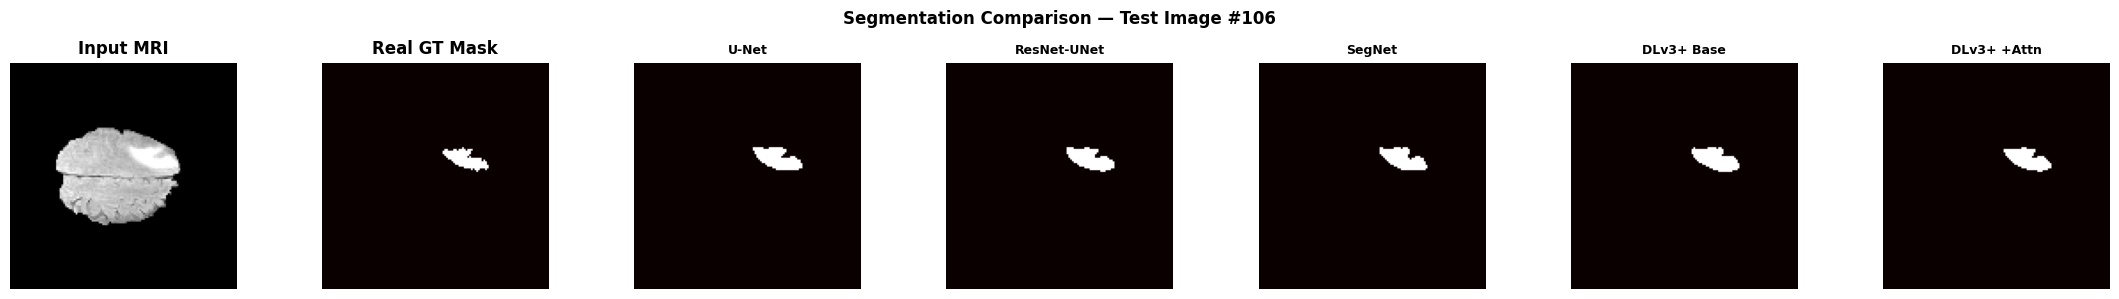

In [ ]:
np.random.seed(42)
sample_indices = np.random.randint(0, len(X_test), size=5)

for idx in sample_indices:
    fig, axes = plt.subplots(1, 7, figsize=(22, 3))
    axes[0].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[0].set_title('Input MRI', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(y_test[idx].squeeze(), cmap='hot')
    axes[1].set_title('Real GT Mask', fontweight='bold'); axes[1].axis('off')
    preds_map = {
        'U-Net':         unet_preds,
        'ResNet-UNet':   resnet_preds,
        'SegNet':        segnet_preds,
        'DLv3+ Base':    baseline_preds,
        'DLv3+ +Attn':   attention_preds,
    }
    for col, (mname, pred_arr) in enumerate(preds_map.items(), start=2):
        axes[col].imshow(pred_arr[idx].squeeze(), cmap='hot')
        axes[col].set_title(mname, fontweight='bold', fontsize=9); axes[col].axis('off')
    plt.suptitle(f'Segmentation Comparison — Test Image #{idx}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

## 17. Save All Models

In [ ]:
save_dir = '/content/drive/MyDrive/brain_segmentation_models_nifti'
os.makedirs(save_dir, exist_ok=True)

unet_model.save(          os.path.join(save_dir, 'unet_brain.keras'))
resnet_model.save(        os.path.join(save_dir, 'resnet_unet_brain.keras'))
segnet_model.save(        os.path.join(save_dir, 'segnet_brain.keras'))
deeplabv3_baseline.save(  os.path.join(save_dir, 'deeplabv3plus_baseline_brain.keras'))
deeplabv3_model.save(     os.path.join(save_dir, 'deeplabv3plus_attention_brain.keras'))
print(f"All 5 models saved to: {save_dir}")

All 5 models saved to: /content/drive/MyDrive/brain_segmentation_models_nifti


## 18. Download Comparison Charts

In [ ]:
from google.colab import files

for fname in [
    'brain_model_comparison_all_metrics.png',
    'brain_dice_accuracy_comparison.png',
    'brain_radar_comparison.png',
    'brain_training_curves.png',
    'brain_deeplabv3_baseline_vs_attention.png',
    'brain_deeplabv3_delta.png',
    'brain_deeplabv3_radar.png',
    'brain_deeplabv3_training_curves.png',
    'brain_deeplabv3_prediction_grid.png',
]:
    files.download(fname)
    print(f"Downloading: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: brain_model_comparison_all_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: brain_deeplabv3_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: brain_deeplabv3_prediction_grid.png
